## **Are markets Markovian?**

A Markov process is a process characterized by the following attribute; In order to predict the probability of the next state of an uncertain sequence, we only need to know the state we currently live in. For example, if we were trying to predict the weather tomorrow, we would only need to use today's weather to make a prediction. The greater the accuracy we get from predictions based on this assumptions, the more likely it is that the underlying process is inherently Markovian.

In the financial world, it is quite appropriate to assume that markets do not behave in a Markovian way, due to the great complexity involved and the external factors. However, while market returns are unlikely to be predicted through these lens, market volatility may tell a different story.

We will try to predict the daily volatility of the S&P 500.

First, we need to download the data we are working with. Daily data from 2021 to 2026 will be used.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ticker = yf.Ticker('^GSPC')

data = ticker.history(start='2021-01-01', end='2026-01-01', interval='1d')

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,3764.610107,3769.989990,3662.709961,3700.649902,5015000000,0.0,0.0
2021-01-05 00:00:00-05:00,3698.020020,3737.830078,3695.070068,3726.860107,4591020000,0.0,0.0
2021-01-06 00:00:00-05:00,3712.199951,3783.040039,3705.340088,3748.139893,6064110000,0.0,0.0
2021-01-07 00:00:00-05:00,3764.709961,3811.550049,3764.709961,3803.790039,5099160000,0.0,0.0
2021-01-08 00:00:00-05:00,3815.050049,3826.689941,3783.600098,3824.679932,4773040000,0.0,0.0


In order to measure the volatility in a given day, we will use the simple formula;
$$ Volatility_t = \frac{High_t - Low_t}{Open_t} $$

In [3]:
data['Volatility'] = (data['High']-data['Low'])/data['Open']

data.dropna()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Volatility
Date,,,,,,,,
2021-01-04 00:00:00-05:00,3764.610107,3769.989990,3662.709961,3700.649902,5015000000,0.0,0.0,0.028497
2021-01-05 00:00:00-05:00,3698.020020,3737.830078,3695.070068,3726.860107,4591020000,0.0,0.0,0.011563
2021-01-06 00:00:00-05:00,3712.199951,3783.040039,3705.340088,3748.139893,6064110000,0.0,0.0,0.020931
2021-01-07 00:00:00-05:00,3764.709961,3811.550049,3764.709961,3803.790039,5099160000,0.0,0.0,0.012442
2021-01-08 00:00:00-05:00,3815.050049,3826.689941,3783.600098,3824.679932,4773040000,0.0,0.0,0.011295
...,...,...,...,...,...,...,...,...
2025-12-24 00:00:00-05:00,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,0.0,0.0,0.004694
2025-12-26 00:00:00-05:00,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,0.0,0.0,0.003485
2025-12-29 00:00:00-05:00,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,0.0,0.0,0.004556


We will plot the daily volatility using bars for visualization.

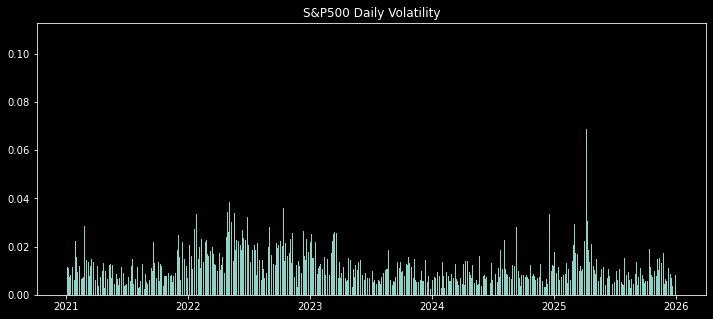

In [4]:
plt.style.use('dark_background')
plt.figure(figsize=(12,5))

plt.bar(data.index, data['Volatility'], width=1.0)

plt.title('S&P500 Daily Volatility') 
plt.show()

Notice that there is an increased volatility period during the 2022-2023 bear market. Additionally, we observe a massive spike in April 2025 where the markets panicked in response to new tariff policies.

### Defining Volatility States

Before constructing the transition matrix, we first define the market states based on daily volatility.

We classify each day into one of the following categories:

- **Quiet**  
  if $Volatility < 0.01$

- **Normal**  
  if $0.01 \leq Volatility \leq 0.02$

- **Trendy**  
  if $Volatility > 0.02$



In [5]:
states = ['Quiet', 'Normal', 'Trendy']

conditions = [
    data['Volatility'] < 0.01,
    (data['Volatility'] >= 0.01) & (data['Volatility'] <= 0.02),
    data['Volatility'] > 0.02
]

data['State'] = np.select(conditions, states)

data['State'].value_counts()

State
Quiet     643
Normal    466
Trendy    146
Name: count, dtype: int64

Based on the criteria we selected, most days appear to be Quiet ($Volatility < 1\%$), while Trendy days ($Volatility > 2\%$) are the rarest.

### Calculating the Transition Matrix

We now need to calculate the transition probability from each state to all others, notated as $A_{ij}$ where $i$ is the current state and $j$ is the next state. Obviously, the sum of each row should give a total probability of $1$.

| From \ To | Normal | Quiet | Trendy |
|----------|--------|--------|--------|
| Normal   | $A_{11}$    | $A_{12}$    | $A_{13}$    |
| Quiet  | $A_{21}$    | $A_{22}$    | $A_{23}$    |
| Trendy  | $A_{31}$    | $A_{32}$    | $A_{33}$    |

We first define 'State' and 'Next State' columns in our data frame, and then count the total transitions.

We will use 80% of the total data for creating the matrix, and the remaining 20% for testing it. 


In [6]:
data['Next_State'] = data['State'].shift(-1)

split_index = int(len(data) * 0.8)
train = data.iloc[:split_index]  # first 80%
test  = data.iloc[split_index:]  # last 20%

transition_counts = pd.crosstab(
    train['State'],
    train['Next_State']
)

transition_counts

Next_State,Normal,Quiet,Trendy
State,,,
Normal,184,139,58
Quiet,130,351,19
Trendy,68,10,45


Now, it is very easy to calculate the transition probabilities. All we need to do is divide each transition count with the total count of its row.

In [7]:
transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1), axis=0
)

transition_matrix

Next_State,Normal,Quiet,Trendy
State,,,
Normal,0.482940,0.364829,0.152231
Quiet,0.260000,0.702000,0.038000
Trendy,0.552846,0.081301,0.365854


Looking at the transition table, we can observe that Quiet days tend to follow Quiet days with a great probability ( $p \approx 0.70$ ) and rarely Trendy days ( $p \approx 0.04$ ). Similarly, Normal days tend to follow Normal days almost half the time, while Trendy days have the highest probability of preceding a Trendy day. Remember that Trendy days represent the smallest percentage of days, therefore it appears that they are clustered together. 

### Testing the model

Let's now test the model on the unseen data. We will use the greatest probability from each row to predict the next state. For example, if the current state is 'Quiet' we will predict 'Quiet' as the next state since it is the most probable transition.

In [8]:
predictions = pd.DataFrame(index= test.index)
predictions['State'] = test['State']

predictions['Next'] = test['State'].map(transition_matrix.idxmax(axis=1))  # Prediction using Markov model
predictions['Correct'] = test['Next_State'] == predictions['Next']

summary = predictions.groupby('State')['Correct'].agg(
    Total = 'count', Markov_Correct = 'sum'
)

most_common = train['State'].value_counts().idxmax()  # Predicting most common state

summary['Common_Correct'] = (
    (most_common == test['Next_State']).groupby(test['State']).sum()
)

summary['Markov_Accuracy'] = summary['Markov_Correct']/summary['Total']
summary['Common_Accuracy'] = summary['Common_Correct']/summary['Total']

print('Markov Accuracy: ', round(summary['Markov_Correct'].sum()/summary['Total'].sum(), 2))
print('Common Accuracy: ', round(summary['Common_Correct'].sum()/summary['Total'].sum(), 2))
summary

Markov Accuracy:  0.66
Common Accuracy:  0.57


,Total,Markov_Correct,Common_Correct,Markov_Accuracy,Common_Accuracy
State,,,,,
Normal,85,44,31,0.517647,0.364706
Quiet,143,111,111,0.776224,0.776224
Trendy,23,10,1,0.434783,0.043478


As expected, the accuracy converges to the maximum transition probability associated with each state, since the model always predicts the most likely next state. This suggests that the out-of-sample data is broadly consistent with the structure captured by the Markov model.

The overall accuracy is relatively high ($\approx 0.66$), especially given that there are three possible states. Compared to a simple strategy that always predicts the most frequent state (in this case, 'Quiet'), the Markov-based approach provides a clear and meaningful improvement.


### Extending to continuous states

It should be noticed that the effectiveness Markov model we created is vastly dependent on the selection of the states we made. Instead of using discrete states, we will now try to use the volatility of the previous and next state as is, and implement a polynomial regression on the data points ($X_t$, $X_{t+1}$) instead of a transition matrix. 

First, we need to define our points $(x,y)=(x_t,x_{t+1})$.

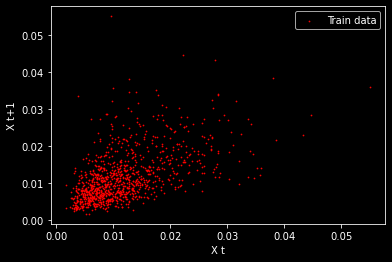

In [9]:
X = train['Volatility'].iloc[:-1] # We skip the last element since we don't have next vol
Y = train['Volatility'].shift(-1).iloc[:-1] # Same here

plt.scatter(X, Y, 0.5, color='red', label='Train data')
plt.xlabel('X t')
plt.ylabel('X t+1')
plt.legend()
plt.show()

In this graph we can observe a clear correlation between the current state $x_t$ and the next state $x_{t+1}$. The greater the volatility on a given day, the more likely the next day also shows greater volatility.

Let's now use linear regression to find the closest approximation to the trend.

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


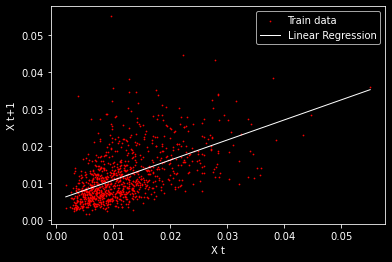

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Prepare data
X_values = X.values.reshape(-1, 1)
Y_values = Y.values

# Fit model
model = LinearRegression().fit(X_values, Y_values)

# Create the line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
Y_line = model.predict(X_line)

plt.scatter(X, Y, 0.5, color='red', label='Train data')
plt.plot(X_line, Y_line, color='white', linewidth=1.0, label='Linear Regression')

plt.xlabel('X t')
plt.ylabel('X t+1')
plt.legend()
plt.show()

It is quite clear that our prediction follows very closely the actual data, but how can we test the effectiveness of the model? One way is to calculate the mean squared error (MSE) as follows;
$$ \mathrm{MSE} = \frac{1}{n} \sum_{t=0}^{T} (x_{t+1} - \hat{x}_{t+1})^2 $$
where $x_{t+1}$ is the actual next day's volatility and $\hat{x}_{t+1}$ is our prediction. We will work on the unseen test data for this. After we calculate our MSE, we will also calculate the MSE from just predicting the average of our train data.

In [11]:
from sklearn.metrics import mean_squared_error

X = test['Volatility'].iloc[:-1] # Again, We skip the last element since we don't have next vol
Y = test['Volatility'].shift(-1).iloc[:-1] # Same here
Y_pred = model.predict(X.values.reshape(-1,1))

pred_mse = mean_squared_error(Y, Y_pred)
mean_mse = mean_squared_error(Y, np.full(Y.size, train['Volatility'].mean()))

print('Linear Regression MSE: ', pred_mse * 100.0)
print('Mean MSE: ', mean_mse * 100.0)

Linear Regression MSE:  0.005654631105255363
Mean MSE:  0.011233748392686272


As expected, our predictions are much better than just predicting the average. 

###  Conclusion

Despite the apparent complexity and unpredictability of financial markets, our results demonstrate that a surprisingly simple approach — leveraging only the previous day's observations — yields strong predictive power for volatility. This finding is not entirely unexpected: real-world events that unsettle markets rarely resolve overnight. Uncertainty tends to persist, compelling investors to continuously hedge and reposition, which in turn sustains elevated volatility across consecutive trading sessions. The momentum embedded in a single day's signal is therefore enough to outperform a naive baseline significantly, suggesting that while markets are far from fully predictable, their short-term volatility structure contains meaningful, exploitable patterns.